- [Model Preparation](#1)
- [Metrics For Evaluation](#2)
    - [R-Squared Score](#2i)
    - [Bias And Variance](#2ii)
    - [Regularization](#regularization)

<h2 id=1>Model Preparation </h2>

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = {
    'Height_cm': [150, 155, 160, 165, 170, 175, 180, 185, 190, 195],
    'Actual_Weight_kg': [50, 60, 62, 68, 70, 77, 80, 82, 90, 92] 
    }
df = pd.DataFrame(data)

X_raw = df[["Height_cm"]]
y = df['Actual_Weight_kg']

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(df[["Height_cm"]])

model_ols = LinearRegression()
model_sgd = SGDRegressor(eta0=0.01,max_iter=1000,random_state=42)

model_ols.fit(X_raw, y) 
model_sgd.fit(X_scaled,y)


test_data = {
    'Height_cm': [152, 162, 172, 182, 192],
    'Actual_Weight_kg': [53, 64, 72, 81, 88]
}
df_test = pd.DataFrame(test_data)
X_test = df_test[['Height_cm']]
X_test_scaled = scaler.transform(df_test[['Height_cm']])

df_test['predicted_weight_ols'] = model_ols.predict(X_test)
df_test['predicted_weight_sgd'] = model_sgd.predict(X_test_scaled)


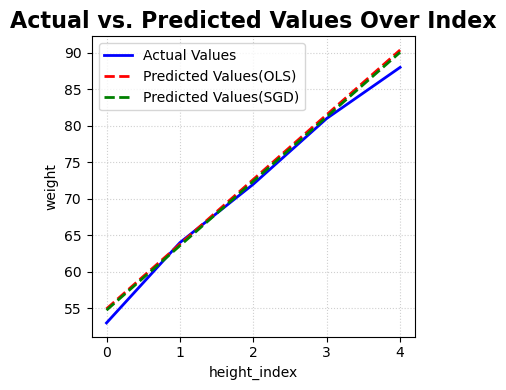

In [2]:
def plot_actual_vs_predicted(y_actual,y_predict_ols,y_predict_sgd,x_label,y_label):
    if isinstance(y_actual,pd.Series):
        y_actual = y_actual.values
    
    plt.figure(figsize=(4,4))    
    plt.plot(y_actual,label='Actual Values',linewidth=2,color='blue')
    plt.plot(y_predict_ols,label="Predicted Values(OLS)",color='red',linestyle='--',linewidth=2)
    plt.plot(y_predict_sgd,label="Predicted Values(SGD)",color='green',linestyle='--',linewidth=2)
    plt.title('Actual vs. Predicted Values Over Index',fontsize=16,fontweight='bold')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()   

plot_actual_vs_predicted(df_test["Actual_Weight_kg"],df_test["predicted_weight_ols"],df_test["predicted_weight_sgd"],'height_index','weight')

## <h2 id=2> Metrics For Evalaluation : </h2>

>- <b style="font-size: 22px;" id='2i'>R-Squared Score : </b> <br>
<p><b>Explains :</b>           How much of the variation in the target variable is explained by the model, higher is better but context matters .</p>

In [3]:
from sklearn.metrics import r2_score

r_square_score_ols = r2_score(df_test["Actual_Weight_kg"],df_test["predicted_weight_ols"])
r_square_score_sgd = r2_score(df_test["Actual_Weight_kg"],df_test["predicted_weight_sgd"])

better_model = "ols" if r_square_score_ols > r_square_score_sgd else  "sgd"
score = max(r_square_score_sgd,r_square_score_ols)

print(f"The {better_model} is better than SGD" if better_model == "ols" else f"The {better_model} is better than OLS ",
      f"\nThere is {score*100:.3f} reduction in variance when we take height in considerations")

The sgd is better than OLS  
There is 98.986 reduction in variance when we take height in considerations


>- ## <b id='2ii'>Bias And Variance : </b> <br>
> "In machine learning, **Bias** and **Variance** represent the two main sources of prediction error. **Bias** measures error caused by overly simple assumptions (underfitting), while **Variance** measures sensitivity to small fluctuations in the training set (overfitting). Balancing them is called the **Bias-Variance Tradeoff**, and the goal is to minimize total generalization error." <br>

>**Bias (Underfitting)** : <br>
   * **Definition:** The systematic error introduced by approximating a complex real-world relationship with a model that is too simple.<br>
   * **Key Characteristic:** High assumptions, low flexibility.<br>
   * **Symptom:** Poor performance on **both** training and test data.<br>
   * **Example:** Fitting a straight line (Linear Regression) to a parabolic data pattern. <br>

>**Variance (Overfitting)** : <br>
   * **Definition:** The degree to which a model's predictions fluctuate when trained on different subsets of data.<br>
   * **Key Characteristic:** High sensitivity to noise, high flexibility.<br>
   * **Symptom:** Near-perfect performance on training data, but **poor performance** on test data.<br>
   * **Example:** Fitting a high-degree polynomial that hits every training point, including random noise.

> ##### 3. Mathematical Intuition :
   The total expected prediction error of a model can be decomposed as:
   $$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$
   * **Irreducible Error:** Inherent noise in the data/environment that no model can eliminate.
   * **Tradeoff Goal:** Find the optimal model complexity that minimizes the sum of $\text{Bias}^2 + \text{Variance}$.

<img src="https://lh3.googleusercontent.com/d/19WtE3e2WKgO31cA49AiJd_-RYXC6lCyu" width="550" height="400" alt="Bias Variance Tradeoff">


- The lower bias and lower variance indicates the perfect or a good ideal fit for any given dataset <br>

<iframe src="https://drive.google.com/file/d/1N-SxmgvmfLLHGUMr8tbJmNp44sya2dk2/preview" width="50%" height="400" allow="autoplay"></iframe>


<h2 id='regularization'> Regularization: 🚗 </h2>
Imagine training a machine learning model is like driving a vehicle down a road to smoothly reach your destination. If another vehicle or unexpected object appears—representing the random noise and outliers in your data—driving rigidly into it would cause a disastrous crash. To prevent a collision, you gently steer your vehicle slightly to the left or right, safely bypassing the specific obstacle while maintaining your overall route. 

**Regularization** acts as this gentle steering correction for an algorithm, pulling the model away from messy data points to prevent **overfitting** and reduce **variation in the testing data**, even if it means accepting a slightly less perfect (**underfit**) path during training.

Don't just minimize the error keeps the coefficient controlled, to not overfit the training data.

- VANILLA Linear Regression (OLS and SGD) works perfectly if :
    - You have plenty of data compared to number of features and columns
    - Features are not strongly correlated (no multicollinearity)
    - The model is not too complex (not too many parameters)

In [4]:
# loading sythentic dataset  to train our model and evaluate which performs better
%run synthetic_train_dataset_for_regularization.py

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # from synthetic dataset

scaler = StandardScaler()
X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)

ols_model = LinearRegression()
sgd_model = SGDRegressor(eta0=0.01,random_state=42,max_iter=1000)

ols_model.fit(X_train_processed,y_train)
sgd_model.fit(X_train_processed,y_train)

ols_y_train_pred = ols_model.predict(X_test_processed)
sgd_y_train_pred = sgd_model.predict(X_test_processed)
r_square_score_ols_train = r2_score(y_test,ols_y_train_pred)
r_square_score_sgd_train = r2_score(y_test,sgd_y_train_pred)

ols_y_test_pred = ols_model.predict(X_test_processed)
sgd_y_test_pred = sgd_model.predict(X_test_processed)

r_square_score_ols = r2_score(y_test,ols_y_test_pred)
r_square_score_sgd = r2_score(y_test,sgd_y_test_pred)

better_model = "ols" if r_square_score_ols > r_square_score_sgd else  "sgd"
score = max(r_square_score_sgd,r_square_score_ols)

print(f"The winning base model is {better_model.upper()}.")
print(f"It explains {score * 100:.2f}% of the total variance in y using the features X.")

The winning base model is OLS.
It explains 98.48% of the total variance in y using the features X.


In [6]:
# Let's Perform Regularization on OLS :

# Lasso Regression :
lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)

lasso.fit(X_train_processed,y_train)

y_train_pred_lasso = lasso.predict(X_train_processed)
lasso_rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred_lasso))
lasso_r2_train = r2_score(y_train,y_train_pred_lasso)

y_test_pred_lasso = lasso.predict(X_test_processed)
lasso_rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred_lasso))
lasso_r2_test = r2_score(y_test,y_test_pred_lasso)

print("\nLasso Regression")
print("Train RMSE:", lasso_rmse_train)
print("Train R²:", lasso_r2_train)
print("Test RMSE:", lasso_rmse_test)
print("Test R²:", lasso_r2_test)
print("Vanilla (OLS) Test R²:",r_square_score_ols)


Lasso Regression
Train RMSE: 0.4994194625632076
Train R²: 0.9848115759753723
Test RMSE: 0.49986552890092295
Test R²: 0.9848056054712951
Vanilla (OLS) Test R²: 0.9848215572186451


In [7]:
# Ridge Regression :
ridge = Ridge(alpha=0.01, max_iter=10000, random_state=42)

ridge.fit(X_train_processed,y_train)

y_train_pred_ridge = ridge.predict(X_train_processed)
ridge_rmse_train = np.sqrt(mean_squared_error(y_train,y_train_pred_ridge))
ridge_r2_train = r2_score(y_train,y_train_pred_ridge)

y_test_pred_ridge = ridge.predict(X_test_processed)
ridge_rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred_ridge))
ridge_r2_test = r2_score(y_test,y_test_pred_ridge)

print("\nRidge Regression")
print("Train RMSE:", ridge_rmse_train)
print("Train R²:", ridge_r2_train)
print("Test RMSE:", ridge_rmse_test)
print("Test R²:", ridge_r2_test)
print("Vanilla (OLS) Test R²:",r_square_score_ols)


Ridge Regression
Train RMSE: 0.49920410074042865
Train R²: 0.9848246723869437
Test RMSE: 0.49960311514450045
Test R²: 0.9848215544468976
Vanilla (OLS) Test R²: 0.9848215572186451


In [8]:
better_model_ols = "ols_lasso" if ridge_r2_test < lasso_r2_test  else  "ols_ridge"
score = max(r_square_score_sgd,r_square_score_ols)

print(f"The winning base model is {better_model_ols.upper()}.")
print(f"It explains {score * 100:.3f}% of the total variance in y using the features X.")

The winning base model is OLS_RIDGE.
It explains 98.482% of the total variance in y using the features X.


In [9]:
# 0.9763093333549799 # ridge_ols_r2_test (better)
# 0.9762110888816296 # lasso_ols_r2_test

 ### New Unseen dataset let's see how our ridge_ols is performing :
   - First we will be preprocessing the test dataset 
   - Then predict & evaluate r2 score

In [10]:
%run synthetic_test_unseen_dataset.py  # Unseen Data generation

# Preprocessing unseen test_set
X_test_processing = scaler.transform(X_test) if(X_test.name == 'unseen_x_test') else print("It's not an unseen dataset.")

y_unseen_test_pred_ridge = ridge.predict(X_test_processing)
ridge_rmse_unseen_test = np.sqrt(mean_squared_error(y_unseen_test,y_unseen_test_pred_ridge))
ridge_r2_unseen_test = r2_score(y_unseen_test,y_unseen_test_pred_ridge)

print("\nRidge Regression (OLS) On Unseen Dataset v/s Seen Dataset:")
print("Unseen Test RMSE:", ridge_rmse_unseen_test)
print("Unseen Test R²:", ridge_r2_unseen_test)
print("Test RMSE:", ridge_rmse_test)
print("Test R²:", ridge_r2_test)
print("Vanilla (OLS) Test R²:",r_square_score_ols)


Ridge Regression (OLS) On Unseen Dataset v/s Seen Dataset:
Unseen Test RMSE: 0.5015306781202196
Unseen Test R²: 0.9849660481855422
Test RMSE: 0.49960311514450045
Test R²: 0.9848215544468976
Vanilla (OLS) Test R²: 0.9848215572186451


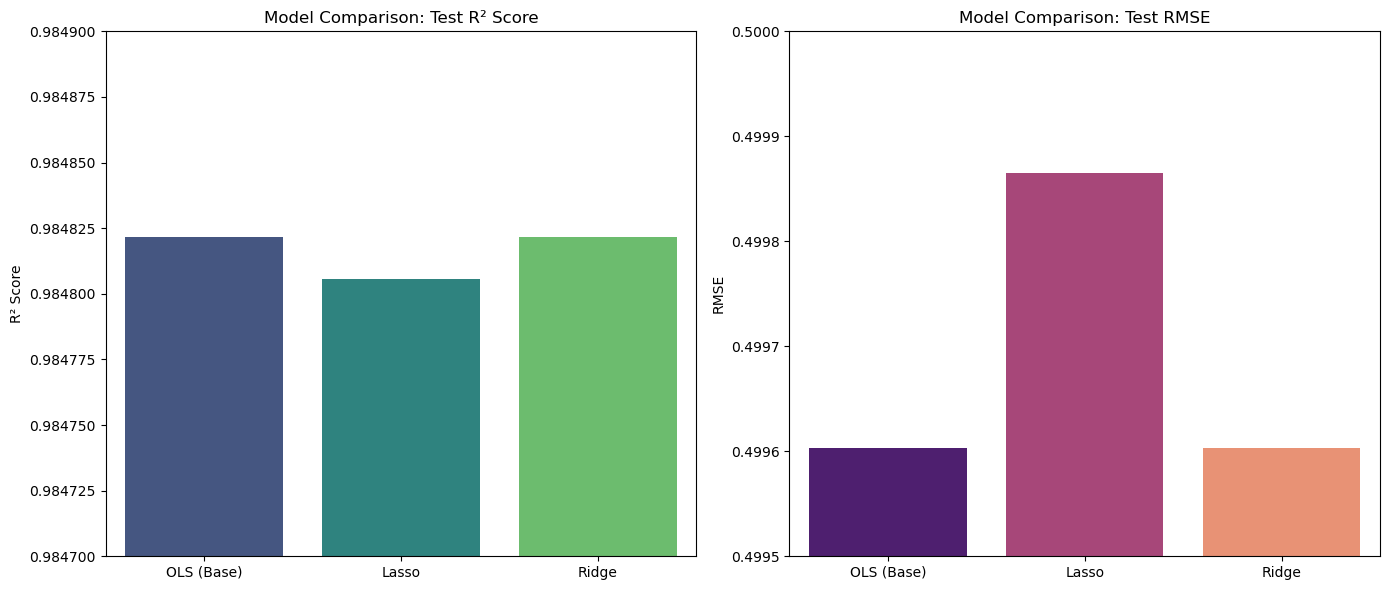

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate OLS RMSE for a complete comparison
ols_rmse_test = np.sqrt(mean_squared_error(y_test, ols_y_test_pred))

# Prepare the data
models = ['OLS (Base)', 'Lasso', 'Ridge']
r2_scores = [r_square_score_ols, lasso_r2_test, ridge_r2_test]
rmse_scores = [ols_rmse_test, lasso_rmse_test, ridge_rmse_test]

# Create a 1x2 grid of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R² Scores
sns.barplot(x=models, y=r2_scores, hue=models, palette='viridis', legend=False, ax=ax1)
ax1.set_title('Model Comparison: Test R² Score')
ax1.set_ylabel('R² Score')
# Zooming in y-axis because the scores are incredibly close (~0.9848)
ax1.set_ylim(0.9847, 0.9849) 

# Plot 2: RMSE Scores
sns.barplot(x=models, y=rmse_scores, hue=models, palette='magma', legend=False, ax=ax2)
ax2.set_title('Model Comparison: Test RMSE')
ax2.set_ylabel('RMSE')
# Zooming in y-axis for visibility 
ax2.set_ylim(0.4995, 0.5000)

plt.tight_layout()
plt.show()

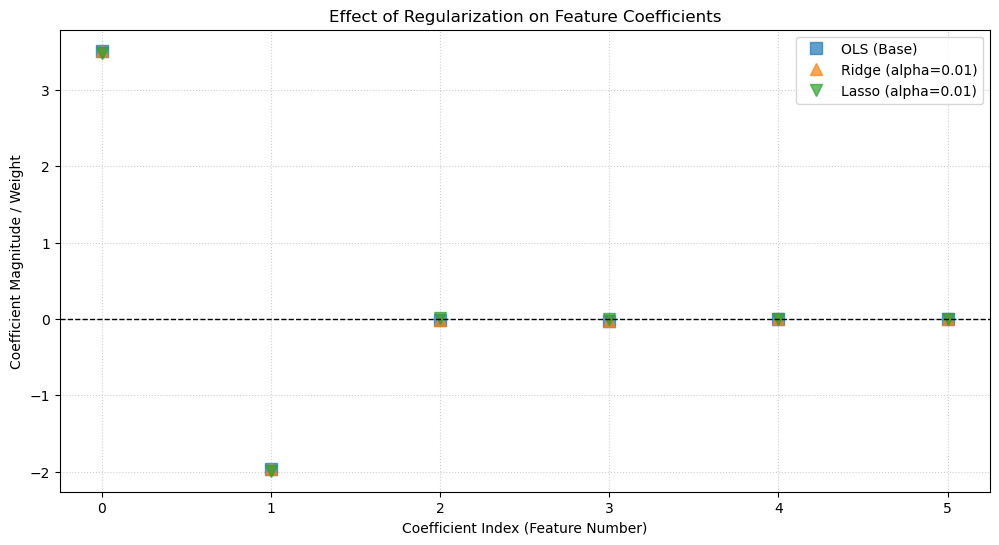

In [12]:
plt.figure(figsize=(12, 6))

# Plotting the coefficients of each model using different markers
plt.plot(ols_model.coef_, 's', label='OLS (Base)', markersize=8, alpha=0.7)
plt.plot(ridge.coef_, '^', label='Ridge (alpha=0.01)', markersize=8, alpha=0.7)
plt.plot(lasso.coef_, 'v', label='Lasso (alpha=0.01)', markersize=8, alpha=0.7)

# Formatting the plot
plt.xlabel('Coefficient Index (Feature Number)')
plt.ylabel('Coefficient Magnitude / Weight')
plt.title('Effect of Regularization on Feature Coefficients')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Adds a reference line at zero
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

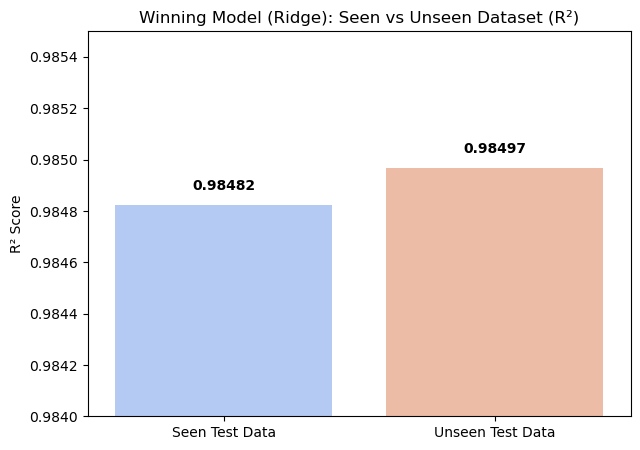

In [13]:
# Prepare the data
datasets = ['Seen Test Data', 'Unseen Test Data']
ridge_r2_comparison = [ridge_r2_test, ridge_r2_unseen_test]

plt.figure(figsize=(7, 5))

# Create the bar plot
ax = sns.barplot(x=datasets, y=ridge_r2_comparison, hue=datasets, palette='coolwarm', legend=False)

# Add exact value labels on top of the bars for clarity
for i, v in enumerate(ridge_r2_comparison):
    ax.text(i, v + 0.00005, f"{v:.5f}", ha='center', va='bottom', fontweight='bold')

# Formatting
plt.title('Winning Model (Ridge): Seen vs Unseen Dataset (R²)')
plt.ylabel('R² Score')
plt.ylim(0.9840, 0.9855) # Zoomed to highlight the slight change

plt.show()

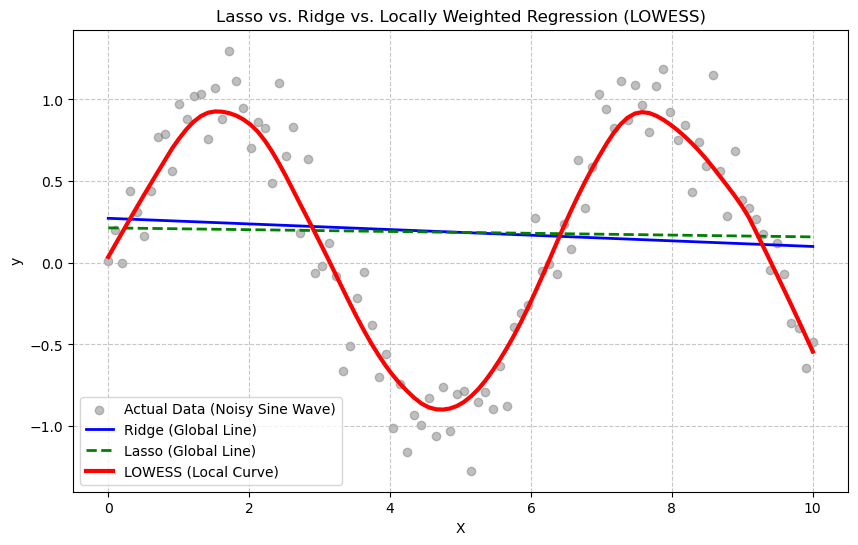

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
import statsmodels.api as sm

# 1. Generate synthetic non-linear data (a noisy sine wave)
np.random.seed(4)
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100) # True pattern + noise

# Reshape X for scikit-learn models (they expect a 2D array)
X_reshaped = X.reshape(-1, 1)

# 2. Fit Ridge Regression (L2 Regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_reshaped, y)
y_ridge = ridge.predict(X_reshaped)

# 3. Fit Lasso Regression (L1 Regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_reshaped, y)
y_lasso = lasso.predict(X_reshaped)

# 4. Fit Locally Weighted Regression (LOWESS)
# 'frac' dictates the window size (e.g., 0.2 means it uses 20% of the closest 
# data points to calculate each local prediction)
lowess = sm.nonparametric.lowess
lowess_result = lowess(y, X, frac=0.2)
y_lowess = lowess_result[:, 1] # Extract the predicted y-values

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data (Noisy Sine Wave)')

plt.plot(X, y_ridge, color='blue', label='Ridge (Global Line)', linewidth=2)
plt.plot(X, y_lasso, color='green', linestyle='--', label='Lasso (Global Line)', linewidth=2)
plt.plot(X, y_lowess, color='red', label='LOWESS (Local Curve)', linewidth=3)

plt.title("Lasso vs. Ridge vs. Locally Weighted Regression (LOWESS)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()